# Day 13 Pre-Class Assignment: Fitting functions to data (curve-fitting) and thinking more about models

### <p style="text-align: right;"> &#9989; Put your name here</p>

<br/>
<img src="https://www.mathworks.com/help/examples/matlab/win64/CurveFittingViaOptimizationExample_01.png" alt="Curve-fitting" width=500px/>


## Goals for today's assignment

* Describe the utility of fitting trendlines to data, in the context of making predictions about the future
* Use best-fit lines to make predictions about future values
* Quantitatively and qualitatively describe how to determine the Goodness of fit for a given line

## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

## 1. Predicting Future Trends

Consider the following dataset showing salinity of water versus depth for Lake Michigan (THIS IS NOT WHAT IT ACTUALLY IS, I JUST MADE IT UP):


<img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse201-F21-data/main/Day-13/Lake_Salinity.jpg" alt="Curve-fitting" width=700px/>

&#9989;&nbsp; **1.1** What would you guess the salinity would be at a depth of 6 meters? At 7 meters?  What makes you think those would be the values?

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **1.2** Make a line connecting the *first* and *last* points and continue it out to a depth of 7 meters. Using the line, predict what the salinity would be at a depth of 6 and 7 meters.

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **1.3** How do the values you determined using your line compare with the values you predicted in 1.1?

<font size=+3>&#9998;</font> *Put your answer here.*


## 2. Determining the Line of Best Fit 

Consider the figure below, which shows the same data set, but with two lines. 


<br/>
<img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse201-F21-data/main/Day-13/Lake_Salinity_Best_Fit_Lines.jpg" alt="Curve-fitting" width=700px/>

&#9989;&nbsp; **2.1** Without doing any calculations (i.e., just looking at the figure), do you think the salinity at a depths of 6 and 7 meters will be closer to values in line 1 or line 2? What is it about that particular line that makes you think it will be more accurate in predicting future values?

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **2.2** Imagine someone asks you to show *quantitatively* that the line you have selected will be more accurate in predicting future values. What is a way you could quantitatively measure how well a line fits some dataset?

Come up with an algorithm--that is, a detailed procedure, like a recipe--for calculating how well a line fits a dataset.

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **2.3** Apply your algorithm to the lines and data and lines in the previous figure. Does the line you choose in part 2.1 fit the data the best according to your algorithm? The data values and the values for the two lines are provided.

In [ ]:
import numpy as np

x_data = np.array([0,1,2,3,4,5])
y_data = np.array([0.5,2.6,3.2,7.7,8.2,11.9])
y_values_line_1 = np.array([2.2, 4.15, 6.1, 8.05, 10., 11.95, 13.9, 15.85])
y_values_line_2 = np.array([5., 6.6, 8.2, 9.8, 11.4, 13., 14.6, 16.2])

<font size=+3>&#9998;</font> *Put your answer here.*


## 3. Using a Computer to Fit a Line 

There’s a tool in the Python package SciPy called `curve_fit` that we can use to fit a mathematical function to data. We’ll be using this extensively in class, so it’s important that you get an idea of how it works.

**Note:** By fitting a function, we mean there are parameters that we can adjust to find the values that best fit the data. 

To use `curve_fit`, you need a minimum of two things:
- A (Python) function that contains the mathematical function you are fitting to your data
- A dataset, consisting of x and y values, that you are fitting your mathematical function to.

Let’s look at an example. 

Below is a set of *x* and *y* values, and we want to fit the following function:

$$y = A \sin(Bx + C)$$

&#9989;&nbsp; **3.1** What parameters are we fitting in this function? 

<font size=+3>&#9998;</font> *Put your answer here.*


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

x = np.array([0.00, 0.71, 1.43, 2.14, 2.86, 3.57, 4.28, 5.00, 5.71, 6.43, 7.14, 7.85])
y = np.array([0.34, 1.42, 1.92, 1.23, -0.08, -1.19, -0.82, -0.14, 0.90, 1.77, 1.78, 0.30])

plt.plot(x,y)

First, we define a Python function that contains the mathematical function we’re fitting.

In [ ]:
def sin_function(x, A, B, C):
    return A * np.sin(B * x + C)

We now have the two pieces needed to use `curve_fit`, so let’s run it and see what we get.

In [ ]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(sin_function, x, y)
print(popt)

From this calling function, we get two values: `popt` and `pcov`. `popt` contains the best fit parameters. **You do not need to worry about `pcov`**.  

If we want to see what our best fit line looks like, we use the following expression:

In [7]:
A_expected = popt[0]  
B_expected = popt[1]
C_expected = popt[2]

y_expected = sin_function(x, A_expected, B_expected, C_expected)

&#9989;&nbsp; **3.2** Give a brief explanation for what the previous line of code is doing.

<font size=+3>&#9998;</font> *Put your answer here.*


In [ ]:
plt.scatter(x, y, label = "data")
plt.plot(x, y_expected, color = "orange", label = "fit")
plt.legend()

### YOUR TURN

One of the simplest functions you can have is a straight line, which takes the form:

$$y = A x + B$$

&#9989;&nbsp; **3.3** What parameters would we fit in this function? 

<font size=+3>&#9998;</font> *Put your answer here.*


### ANSWER ###

We're fitting the parameters $A$ and $B$.

&#9989;&nbsp; **3.4** Fit a straight line to the x and y dataset provided below. Specify what the best fit parameters are and make a plot showing your best fit line.

In [ ]:
x = np.array([0,1,2,3,4,5])
y = np.array([0.5,2.6,3.2,7.7,8.2,11.9])

#Put your code here


[2.23714286 0.09047619]


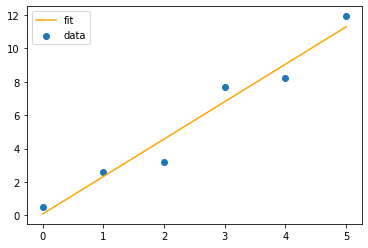

In [1]:
### ANSWER ###

from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def linear_function(x, A, B):
    return A * x + B

x_data = np.array([0,1,2,3,4,5])
y_data = np.array([0.5,2.6,3.2,7.7,8.2,11.9])
popt, pcov = curve_fit(linear_function, x_data, y_data)
print(popt)

y_expected = linear_function(x_data, popt[0], popt[1])

plt.scatter(x_data, y_data, label = "data")
plt.plot(x_data, y_expected, color = "orange", label = "fit")
plt.legend()

## 4. Determining Goodness of Fit

&#9989;&nbsp; **4.1** Compare your best fit line to the line provided in Section 2. Which one appears to fit the data better? 

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **4.2** Turn the algorithm you developed in part 2.2 for measuring how well a line fits the data into code and apply it to your best fit line. How does this value for goodness of fit compare to the one you derived in part 2.3?  

In [ ]:
#Put your code here


<font size=+3>&#9998;</font> *Put your answer here.*


---
## 5. Project brainstorming

For the last part of this pre-class assignment you're going to start thinking about your semester project. **Make sure to read all of the appropriate content and complete the brainstorming section!**

### Semester Project Details

On the course website, there is now a file called "CMSE201_SemesterProjectDetails.pdf".

&#9989;&nbsp; **Task**: Read that file in its entirety.

### Example projects

Dr. Murillo, an instructor from a previous semester of CMSE 201, put together an example of what a semester project might look like and posted it on his research group's website: https://murillogroupmsu.com/wine/

&#9989;&nbsp; **Task**: Read through his example to get a sense for the kinds of thing you could do for your semester project. Don't worry if there are parts you don't understand, if you decide you want to use some of the python packages he used, there will be time to figure them out!

In additional to that example, there are three additional examples available on the course website. They are named:
* CMSE201_ExampleProject_1.pdf
* CMSE201_ExampleProject_2.pdf
* CMSE201_ExampleProject_3.pdf

&#9989;&nbsp; **Task**: Skim through these examples as well. Again, don't worry if there are parts you don't understand -- we're still learning things in the course! Also, just because these are examples of past projects, it does not necessarily mean that these examples met all of the project requirements. Make sure you have carefully read the project details document as you embark on your project!

#### In addition to those examples, here are some of the project topics from previous semesters:

1. (modeling) comparing classical and quantum mechanics
2. (modeling) gravitational problems, including solar systems and satellites
3. (data) Brexit
4. (data) beer drinking habits
5. (data/modeling) forecasting financial trends
6. (data) machine learning using Python's Scikit Learn
7. (data) global warming trends
8. (modeling) finding the shortest path between two point in a Google map
9. (modeling) molecular dynamics of a two-dimensional fluid
10. (modeling) agent-based model of a fusion in the sun
11. (modeling) a solution to the "Queens Problem" in chess
12. (modeling) agent-based model of people's happiness as a function of city they live in
13. (data) analysis of economic data in Venezuela and how it relates to politics

and so on...

Since we are still early in the semester, it is important to think about not only what you have already learned, but also what you will be learning in the remaining weeks of the semester. You can and should use concepts from the class in your projects that we haven't covered yet. Topics that we still have yet to cover include:
* Solving systems of differential equations to build compartmental models (e.g. to model spread of disease or population dynamics)
* Using agent-based models to determine how individuals rules and actions can lead to large-scale results (e.g. modeling forest fires or social dynamics)
* Using random numbers in models and modeling random walks

and as a reminder, the topics we've covered so far include:

* Writing if statements, for loops, and while loops to calculate values and evolve systems
* Analyzing data with NumPy
* Anaylzing data with Pandas
* Linear regression and fitting models to data.

You are encourage to look up any/all of these topics to gain more insight into them. If any of these ideas intrigue you, talk with your instructor about them to get you kick started before we get to it in class.

### Brainstorming project ideas

Now that you've had a chance to read the semester project details and review some examples of what a project might look like, it's time to start brainstorming some ideas for what sort of topic you might like to explore for your project.

&#9989;&nbsp; **Task**: In each of the *four* markdown cells below, come up with a possible topic that you might want to pursue for your semester project. Along with the topic, brainstorm if you'll try to pursue the topic by analyzing data or if you'll try to create a computational model. You should mention what sort of data or models you think you might want to use to try to answer a questions related to the the topic. Each cell should end up having a short paragraph of your brainstorming ideas.

**Try to come up with two data-driven topics and two modeling-focused topics**.

Try not to spend more than about 20 minutes on this. The idea is to get to you thinking of several projects that would be interesting to you. Later, you will decide on one and propose it to the class in the form of a short presentation. If you feel like you are struggling to come up with project ideas, this is a good time to check in with your instructor!

---
## Follow-up Questions

Copy and paste the following questions into the appropriate box in the assignment survey include below and answer them there. (Note: You'll have to fill out the assignment number and go to the "NEXT" section of the survey to paste in these questions.)

1. What topic idea(s) do you have for your semester project at this time?

2. What modeling or data analysis techniques do you envision using to complete your project?

---
## Assignment wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

In [ ]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://cmse.msu.edu/cmse201-pc-survey" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Pre-class assignments" folder, find the appropriate submission link, and upload it there.

See you in class!

&#169; Copyright 2021,  [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.